# Fase 1 — Selección de algoritmo: máscara neuronal vs geométrico

Primera fase de la narrativa. Se compara el beamformer **geométrico** (DS robusto
y MVDR-geo adaptativo) contra el **ciego** por máscara neuronal (**NM-MVDR**), y se
justifica elegir NM-MVDR por robustez. **El WPE ya no forma parte del sistema**
(`use_wpe=False` en todas las grillas).

- **P1 — alta diversidad acústica, sin errores.** Barrido amplio de RT60 × DOA-target
  × distancia × locutor × layout-interferentes × iSIR, con `error_*`/mismatch en 0.
  El geométrico recibe la posición **verdadera**, así que compite en igualdad → muestra
  que NM-MVDR al menos empata (y suele ganar con reverberación) en todo el envelope.
- **P2 — baja diversidad + errores de sensor/DOA.** Acústica fija; se barren por
  separado error de DOA, desajuste de ganancia y de fase. El geométrico se rompe
  (autocancelación por WNG alto / apuntado erróneo); NM-MVDR queda plano.
- **P3 — ¿de dónde viene la brecha? (techos oracle).** **NM-MVDR** (máscara DTLN)
  contra sus cotas superiores en el *mismo* pipeline Souden-MVDR — **Oracle-mask**
  (máscara ideal desde las señales limpias) y **Oracle-SCM** (covarianzas Φ_SS/Φ_NN
  directas de las limpias, sin máscara) — más **MVDR-geo+SCM-oracle**, que usa esa
  misma Φ_NN ideal pero resuelve el MVDR clásico con el steering vector *geométrico*.
  La descomposición de la brecha responde la pregunta:
  - `Oracle-mask − NM-MVDR` = **error de estimación de máscara** (techo del NM-MVDR:
    lo que se ganaría con una máscara perfecta y el mismo modelo mask-based),
  - `Oracle-SCM − Oracle-mask` = **límite del modelo de máscara en sí** (techo del
    MVDR: lo que ni la máscara ideal puede recuperar porque las SCM se siguen
    estimando desde la mezcla enmascarada),
  - `Oracle-SCM − MVDR-geo+SCM-oracle` = **costo del modelo geométrico** con
    estadística de ruido perfecta (cuánto cuesta describir la fuente con un RTF de
    campo cercano en una sala real, sin ningún error de estimación de por medio).
  Diversidad acústica moderada pero **con variación de RT60 e iSIR**, para exponer
  los puntos donde DTLN se cae y los oracles no. Post-filtro DTLN **apagado**.

**Nota sobre la carga diagonal.** Todos los beamformers la calculan igual
(`load = max(rel·tr(Φ)/M, piso)`), pero **con valores distintos, elegido cada uno
en su óptimo**: el MVDR geométrico necesita carga pesada (`rel=1e-2`) porque sin
regularizar se autocancela el target con un steering vector desajustado por la
reverberación, y el de máscara rinde mejor con carga liviana (`rel=1e-6`) porque su
información espacial sale de los datos. Barrido de verificación sobre MIRD: el
ranking no cambia con carga común 1e-6, con carga común 1e-2, ni con cada uno en su
óptimo.

*Salida:* se elige **NM-MVDR** por robustez, y se caracteriza cuánto de su brecha
al ideal es error de máscara y cuánto es del modelo.

**Correr en orden:** Selector → Setup → Config → (P1 / P2 / P3 según los flags) → Figuras.


## Selector de pruebas — qué correr en esta sesión

Poné en `True` solo las pruebas que querés (re)correr. Setup y Config se ejecutan
siempre; las celdas de las pruebas apagadas se saltean solas (no pisan resultados
anteriores). Cada ejecución de la celda de Config abre una carpeta de sesión nueva
`F1_<RUN_ID>/`, así que lo corrido en esta sesión queda junto.


In [1]:
# ============== QUÉ PRUEBAS CORRER EN ESTA SESIÓN ==============
RUN_P1 = True   # alta diversidad acústica: DS / MVDR-geo / NM-MVDR
RUN_P2 = True   # errores de sensor y DOA (robustez del geométrico)
RUN_P3 = True    # techos oracle: NM-MVDR vs Oracle-mask vs Oracle-SCM
# ===============================================================
print("a correr:", [n for n, v in
      [("P1", RUN_P1), ("P2", RUN_P2), ("P3", RUN_P3)] if v] or "nada")


a correr: ['P1', 'P2', 'P3']


## Setup — ejecutar una vez por sesión de Colab
Montar Drive, clonar el repo, instalar dependencias y actualizar el código.

In [2]:
# Import the drive module from Google Colab
from google.colab import drive

# Mount Google Drive to the virtual machine
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 3. Descargar tu código temporalmente
%cd /content
!git clone https://github.com/MatiasVereert/Vision-Aided-Beamformer.git

/content
Cloning into 'Vision-Aided-Beamformer'...
remote: Enumerating objects: 1895, done.
remote: Counting objects: 100% (1200/1200), done.
remote: Compressing objects: 100% (739/739), done.
remote: Total 1895 (delta 666), reused 967 (delta 443), pack-reused 695 (from 1)
Receiving objects: 100% (1895/1895), 46.23 MiB | 39.41 MiB/s, done.
Resolving deltas: 100% (1102/1102), done.


In [4]:
import os

WHL = "/content/drive/MyDrive/colab_wheels"   # cache persistente de wheels en Drive

# CONSTRUIR (git+ para las libs de GitHub).
BUILD = [
    "noisereduce", "mir_eval", "pystoi", "pesq", "paderbox", "ai_edge_litert",
    "git+https://github.com/fgnt/pb_bss.git",
    "git+https://github.com/LCAV/pyroomacoustics.git",
    "git+https://github.com/fgnt/nara_wpe.git",
    "git+https://github.com/fakufaku/fast_bss_eval.git",
]
# INSTALAR desde cache: NOMBRES (no git+, si no pip vuelve a clonar).
INSTALL = [
    "noisereduce", "mir_eval", "pystoi", "pesq", "paderbox", "ai_edge_litert",
    "pb_bss", "pyroomacoustics", "nara_wpe", "fast_bss_eval",
]

# Reconstruye el cache SOLO si la lista de paquetes cambio (manifest) -> se
# autocura si agrego/saco un paquete, sin tener que borrar el cache a mano.
manifest = os.path.join(WHL, ".manifest.txt")
key = "\n".join(sorted(BUILD))
need_build = (not os.path.isfile(manifest)) or open(manifest).read() != key

if need_build:
    os.makedirs(WHL, exist_ok=True)
    print("[*] (Re)construyendo cache de wheels en Drive (una vez por cambio de lista)...")
    !pip wheel --wheel-dir=$WHL {" ".join(BUILD)}
    with open(manifest, "w") as fh:
        fh.write(key)
    print("[*] Cache actualizado en", WHL)

!pip install --no-index --find-links=$WHL {" ".join(INSTALL)}
print("[*] Paquetes instalados desde el cache de Drive.")
# Si Colab actualiza Python y falla un import:  !rm -rf $WHL  (se reconstruye solo)

Looking in links: /content/drive/MyDrive/colab_wheels
Processing ./drive/MyDrive/colab_wheels/noisereduce-3.0.3-py3-none-any.whl
Processing ./drive/MyDrive/colab_wheels/mir_eval-0.8.2-py3-none-any.whl
Processing ./drive/MyDrive/colab_wheels/pystoi-0.4.1-py2.py3-none-any.whl
Processing ./drive/MyDrive/colab_wheels/pesq-0.0.4-cp313-cp313-linux_x86_64.whl
Processing ./drive/MyDrive/colab_wheels/paderbox-0.0.8-cp313-cp313-linux_x86_64.whl
Processing ./drive/MyDrive/colab_wheels/ai_edge_litert-2.2.0-cp313-cp313-manylinux_2_27_x86_64.whl
Processing ./drive/MyDrive/colab_wheels/pb_bss-0.0.0-cp313-cp313-linux_x86_64.whl
Processing ./drive/MyDrive/colab_wheels/pyroomacoustics-0.10.2.dev6+gff7d61f21-cp313-cp313-linux_x86_64.whl
Processing ./drive/MyDrive/colab_wheels/nara_wpe-0.0.11-py3-none-any.whl
Processing ./drive/MyDrive/colab_wheels/fast_bss_eval-0.1.4-py3-none-any.whl
Processing ./drive/MyDrive/colab_wheels/cached_property-2.0.1-py3-none-any.whl (from paderbox)
Processing ./drive/MyDrive/

[*] Paquetes instalados desde el cache de Drive.


In [5]:
%cd /content/Vision-Aided-Beamformer
!git pull origin main

/content/Vision-Aided-Beamformer
From https://github.com/MatiasVereert/Vision-Aided-Beamformer
 * branch            main       -> FETCH_HEAD
Already up to date.


## Config compartida (Fase 1)

In [6]:
import sys, os, numpy as np, shutil
from datetime import datetime

repo_root = '/content/Vision-Aided-Beamformer'
src_path = os.path.join(repo_root, 'src')
for p in (repo_root, src_path):
    if p not in sys.path: sys.path.append(p)
%cd {src_path}

try:
    import tensorflow as tf
    TFLITE_AVAILABLE = True
except ImportError:
    TFLITE_AVAILABLE = False

from evaluation.full_benchmark_test_dtln_mird import run_mird_grid_search
from evaluation.bf_wrappers import (DS, MVDR_Recursive, NM_MVDR, MPDR_Recursive,
                                    ORACLE_MB_MVDR_SOUDEN, SOUDEN_ORACLE_SCM,
                                    MVDR_GEO_ORACLE_SCM)
from propagation.mird_loader import MirdDatasetProvider

m1 = os.path.join(repo_root, "src/dnn_denoise/models/model_quant_1.tflite")
m2 = os.path.join(repo_root, "src/dnn_denoise/models/model_quant_2.tflite")
interpreter_1 = interpreter_2 = None
if TFLITE_AVAILABLE and os.path.exists(m1) and os.path.exists(m2):
    interpreter_1 = tf.lite.Interpreter(model_path=m1); interpreter_1.allocate_tensors()
    interpreter_2 = tf.lite.Interpreter(model_path=m2); interpreter_2.allocate_tensors()
    print("[*] DTLN TFLite OK.")
else:
    print("[!] Sin DTLN interpreters.")

input_dir = "/content/drive/MyDrive/Benchmarks_tesis/inputs"
mird_dir  = "/content/drive/MyDrive/Benchmarks_tesis/rirs"
provider = MirdDatasetProvider(root_dir=mird_dir)

# ===================== PERILLAS =====================
DURATION = 15
# ===================================================

TARGETS = [os.path.join(input_dir, f) for f in [
    "p002_emo_adoration_sentences.wav",
    "p008_emo_contentment_sentences.wav",
]]
INTERF = [os.path.join(input_dir, f) for f in [
    "techno_gated commune.wav",
    "hairdryer_07_SH_MKH800.wav",
    "drill_07_RHODE_NT1.wav",
]]

base_config = {
    'fs': 16000, 'duration': DURATION, 't_early': 0.050,
    'array_center': [3.0, 3.0, 1.2], 'mird_spacing': "3-3-3-8-3-3-3",
    'snr_db': 60.0,
    'source_path': TARGETS[0], 'interf_paths': INTERF,
    # --- WPE ELIMINADO DEL SISTEMA (use_wpe=False en toda grilla). Estos escalares
    #     solo existen porque el benchmark los exige en scene_base_config; no operan.
    'wpe_taps': 5, 'wpe_delay': 2, 'wpe_alpha': 0.9999,
    'wpe_stft_size': 512, 'wpe_stft_shift': 128,
    'stft_window': 512, 'stft_overlap': 384,
    'dtln_model_path': m1,
    'eval_references': ['early'],
}

# --- PROCESADORES (Fase 1: la comparación de algoritmo) ---
# DS = geométrico robusto (WNG bajo); MVDR-geo = geométrico adaptativo (frágil);
# NM-MVDR = máscara neuronal (ciego).
#
# CARGA DIAGONAL — los dos MVDR usan la MISMA fórmula,
#     load = max(carga_relativa * tr(Phi)/M , piso_absoluto),
# pero con VALORES DISTINTOS, y es deliberado: cada uno corre en el punto donde
# rinde mejor, medido con un barrido sobre MIRD (RT 360/610 ms, 24 escenas).
#   MVDR-geo  -> rel = 1e-2 (carga PESADA). Con 1e-6 no gana supresión (mismo SIR)
#                y pierde ~3.8 dB de SDR y ~3.2 dB de SAR: sin regularizar, el
#                desajuste del steering vector en sala le hace cancelar el propio
#                target. La carga es lo que lo mantiene en pie.
#   NM-MVDR   -> rel = 1e-6 (carga LIVIANA). Su óptimo es el opuesto: subirla a 1e-2
#                le cuesta 2.7 dB de SDR y 7.7 dB de SIR. Como su información
#                espacial sale de los datos, puede cavar nulos profundos sin
#                lastimarse.
# En NM_MVDR (familia Souden) el parámetro `min_loading` ES la escala relativa; en
# MVDR_Recursive están separados en `rel_loading` (escala) y `min_loading` (piso).
# Igualar los valores no cambia el ranking: NM-MVDR gana con carga común 1e-6, con
# carga común 1e-2 y con cada uno en su óptimo.
processors_dict = {
    "DS":       DS(),
    "MVDR-geo": MVDR_Recursive(rel_loading=1e-2, min_loading=1e-6),
    "MPDR": MPDR_Recursive(min_loading=1e-6),
    "NM-MVDR":  NM_MVDR(min_loading=1e-6, alpha=0.99)

}

# --- PROCESADORES DE P3 (techos oracle: sin geometría) ---
# Los tres comparten EXACTAMENTE el mismo core (Souden MVDR recursivo, mismo
# min_loading y alpha) y el mismo framing STFT: lo unico que cambia es de donde
# sale la informacion espacial.
#   NM-MVDR     -> mascara DTLN estimada de la mezcla (el sistema real).
#   Oracle-mask -> mascara ideal desde las limpias; SCM aun estimadas de la mezcla
#                  enmascarada  => techo del NM-MVDR (error de mascara).
#   Oracle-SCM  -> Phi_SS/Phi_NN directas de las limpias, sin mascara
#                  => techo del MVDR en si (limite del modelo de mascara).
#   MVDR-geo+SCM-oracle -> MVDR clasico w = Phi_NN^-1 d / (d^H Phi_NN^-1 d) con la
#                  MISMA Phi_NN oracle pero d GEOMETRICO (posicion de la fuente)
#                  => aisla el costo del modelo geometrico con ruido perfecto.
# CARGA DIAGONAL: misma formula para los cuatro, valores distintos a proposito
# (mismo criterio que en processors_dict). El geometrico con Phi_NN oracle mejora
# hasta rel=1e-2 en PESQ/STOI/SDR (1e-6 -> 1e-2: PESQ 0.017 -> 0.073, SDR 1.10 ->
# 2.90 dB) a cambio de ~2 dB de SIR: con menos carga se autocancela por el desajuste
# del steering vector en sala. Como marca un TECHO, se lo corre en SU mejor punto
# -> la brecha contra Oracle-SCM no se puede atribuir a sub-regularizarlo. Para
# igualarlo al valor de la familia mask-based, poner rel_loading=1e-6.
# sharpen_exp explicito: 4.0 en el camino DTLN (el historico) y 1.0 en el oracle
# (IRM suave, sin realce). Es la perilla a tocar si se quiere aislar el efecto del
# realce de la mascara del efecto de su origen.
processors_P3 = {
    #"NM-MVDR":     NM_MVDR(min_loading=1e-6, alpha=0.99, sharpen_exp=4.0),
    "Oracle-mask": ORACLE_MB_MVDR_SOUDEN(min_loading=1e-6, alpha=0.99, sharpen_exp=1.0),
    #"Oracle-SCM":  SOUDEN_ORACLE_SCM(min_loading=1e-6, alpha=0.99),
    #"MVDR-geo+SCM-oracle": MVDR_GEO_ORACLE_SCM(rel_loading=1e-2, alpha=0.99),
}

# Flags del selector: si se salteo esa celda, se corre todo (comportamiento previo).
for _flag in ("RUN_P1", "RUN_P2", "RUN_P3"):
    globals().setdefault(_flag, True)

import json
# RUN_ID con SEGUNDOS -> no hay colisiones de minuto. TODAS las sub-corridas de
# ESTA ejecucion de la celda caen bajo UNA carpeta de sesion F1_<RUN_ID>/, asi que
# lo que va junto queda junto. results_fases/ separa de los viejos Prueba_*.
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
SESS_T = f"/content/results_temp/F1_{RUN_ID}"
SESS_D = f"/content/drive/MyDrive/Tesis_Beamformers/results_fases/F1_{RUN_ID}"

def run(grid, name, procs=processors_dict, apply_dtln_post=True):
    t = os.path.join(SESS_T, name); d = os.path.join(SESS_D, name)
    os.makedirs(t, exist_ok=True); os.makedirs(d, exist_ok=True)
    df = run_mird_grid_search(grid_params=grid, dataset_provider=provider,
                              processors=procs, scene_base_config=base_config,
                              output_dir=t, interpreter_1=interpreter_1,
                              interpreter_2=interpreter_2, save_catalog=False,
                              apply_dtln_post=apply_dtln_post)
    # DONE.json = marca de COMPLETITUD: se escribe SOLO si run_mird_grid_search
    # termino OK. Si una corrida crashea, la carpeta queda SIN DONE.json -> se
    # identifica como incompleta.
    n_proc = len(procs); n_cells = len(df) // max(n_proc, 1)
    json.dump({"run_id": RUN_ID, "phase": "F1", "experiment": name,
               "status": "COMPLETE", "rows": int(len(df)), "n_processors": n_proc,
               "n_cells": int(n_cells), "processors": list(procs.keys()),
               "dtln_post": bool(apply_dtln_post),
               "grid": {k: str(v) for k, v in grid.items()},
               "finished_utc": datetime.utcnow().isoformat() + "Z"},
              open(os.path.join(t, "DONE.json"), "w"), indent=2, ensure_ascii=False)
    shutil.copytree(t, d, dirs_exist_ok=True)
    print(f"[EXITO] {name} -> {d}  ({len(df)} filas, {n_proc} proc, {n_cells} celdas)")
    return df, d

print(f"Config Fase 1 lista. RUN_ID={RUN_ID}")
print(f"sesion -> {SESS_D}")
print("procesadores P1/P2 =", list(processors_dict.keys()))
print("procesadores P3    =", list(processors_P3.keys()))
print("flags:", {k: globals()[k] for k in ("RUN_P1", "RUN_P2", "RUN_P3")})

/content/Vision-Aided-Beamformer/src


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


[*] DTLN TFLite OK.
[MirdDatasetProvider] Successfully indexed 234 RIR files from: /content/drive/MyDrive/Benchmarks_tesis/rirs
Config Fase 1 lista. RUN_ID=20260829_025346
sesion -> /content/drive/MyDrive/Tesis_Beamformers/results_fases/F1_20260829_025346
procesadores P1/P2 = ['DS', 'MVDR-geo', 'MPDR', 'NM-MVDR']
procesadores P3    = ['Oracle-mask']
flags: {'RUN_P1': True, 'RUN_P2': True, 'RUN_P3': True}


## P1 — alta diversidad acústica (resultado general, sin errores)

In [7]:
if RUN_P1:
    # Barre RT60 x DOA-target x distancia x locutor x layout-interf x iSIR, con
    # mismatch y error_* en 0. Grilla marginalizada: recortá listas si tarda mucho.
    # MIRD disponible: RT60 {0.160,0.360,0.610}, dist {1,2} m, ángulos ±90 en pasos de 15°.
    INTERF_P1 = [
        [(45, 1.0, 0)],                                   # 1 interferente
        [(30, 1.0, 0), (-45, 1.0, 1)],                    # 2 interferentes
        [(30, 1.0, 0), (-30, 1.0, 1), (60, 1.0, 2)],      # 3 interferentes
    ]
    grid_P1 = dict(
        rt60=[0.160, 0.360, 0.610],
        target_angle=[0, 30, 60],
        target_dist=[1.0, 2.0],
        source_path=TARGETS,
        interf_configs=INTERF_P1,
        isir_db=[-5, 0, 5, 10],
        use_wpe=[False],
        mismatch_gain=[0], mismatch_phase=[0],
        error_angle_deg=[0.0], error_distance_m=[0.0],
    )
    df_P1, dir_P1 = run(grid_P1, "P1_diversidad")
else:
    print("[i] P1 salteada (RUN_P1=False).")


[*] t_early FIXED at 50.0 ms (decoupled from wpe_delay).
[*] Total experiments to run: 432 per processor (4 processors -> 1728 rows).


MIRD Benchmark   0%|          | 0/432 exp [00:00<?, ?exp/s]

   0%|          | 0/1

/content/Vision-Aided-Beamformer/src/utils/audio.py:32: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_file, data = wavfile.read(filename)
 [*] [REF-MIC] canal 4 de 8 (metricas + proyeccion de TODOS los beamformers).
/usr/local/lib/python3.13/dist-packages/fast_bss_eval/numpy/helpers.py:69: RuntimeWarning: divide by zero encountered in log10
  return 10.0 * np.log10(ratio)




=== BATCH COMPLETED IN 141.74 MINUTES ===
[EXITO] P1_diversidad -> /content/drive/MyDrive/Tesis_Beamformers/results_fases/F1_20260829_025346/P1_diversidad  (1728 filas, 4 proc, 432 celdas)


/tmp/ipykernel_2187/2572028829.py:150: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "finished_utc": datetime.utcnow().isoformat() + "Z"},


### Preview rápido P1 (en memoria — no necesita las corridas de P2)

/tmp/ipykernel_2187/3250297453.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_P1, x="processor", y=col, order=_pr, palette=_c, ax=ax, fliersize=1)
/tmp/ipykernel_2187/3250297453.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_P1, x="processor", y=col, order=_pr, palette=_c, ax=ax, fliersize=1)


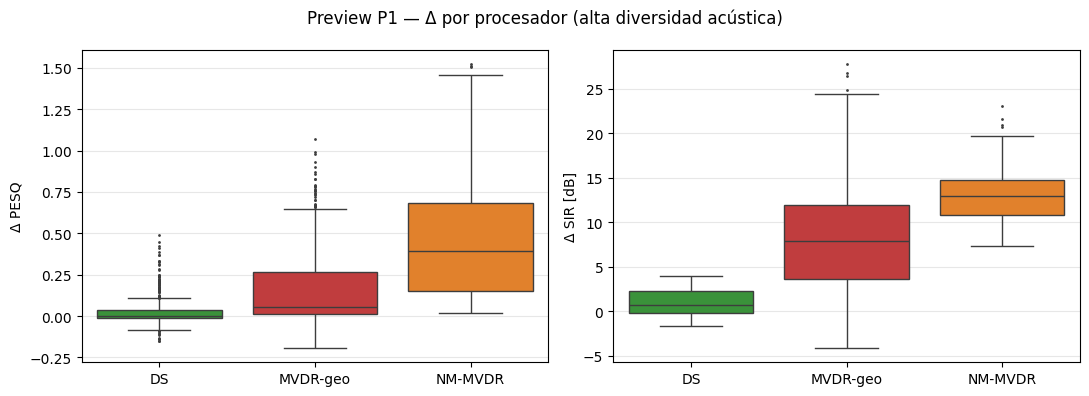

In [8]:
if "df_P1" in globals():
    # Boxplots Δ por procesador sobre la diversidad de P1. Usa df_P1 en memoria.
    import matplotlib.pyplot as plt, seaborn as sns
    _pr = ["DS", "MVDR-geo", "NM-MVDR"]
    _c  = {"DS":"tab:green", "MVDR-geo":"tab:red", "NM-MVDR":"tab:orange"}
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, (col, lbl) in zip(axes, [("Delta_tot_PESQ_early","Δ PESQ"),
                                     ("Delta_tot_SIR_early","Δ SIR [dB]")]):
        if col not in df_P1.columns: continue
        sns.boxplot(data=df_P1, x="processor", y=col, order=_pr, palette=_c, ax=ax, fliersize=1)
        ax.set_xlabel(""); ax.set_ylabel(lbl); ax.grid(alpha=0.3, axis="y")
    plt.suptitle("Preview P1 — Δ por procesador (alta diversidad acústica)")
    plt.tight_layout(); plt.show()
else:
    print("[i] Preview P1: corré P1 en esta sesión para verlo.")


## P2 — baja diversidad + errores de sensor/DOA (robustez)

In [9]:
if RUN_P2:
    # Acústica FIJA (RT60=360 ms, target broadside 0/1 m, iSIR=0, un layout de 3 interf).
    # Tres barridos 1D independientes: error de DOA | ganancia | fase.
    FIXED_P2 = dict(
        rt60=[0.360], target_angle=[0], target_dist=[1.0],
        source_path=TARGETS,
        interf_configs=[[(30, 1.0, 0), (-15, 1.0, 1), (45, 1.0, 2)]],
        isir_db=[0], use_wpe=[False],
    )
    # (a) error de DOA -> solo afecta a DS y MVDR-geo (usan source_pos); NM-MVDR plano.
    grid_P2_doa = dict(FIXED_P2,
        mismatch_gain=[0], mismatch_phase=[0],
        error_angle_deg=[0, 2, 5, 10, 15], error_distance_m=[0.0])
    # (b) desajuste de GANANCIA entre sensores.
    grid_P2_gain = dict(FIXED_P2,
        error_angle_deg=[0.0], error_distance_m=[0.0],
        mismatch_gain=[0, 1, 2, 3], mismatch_phase=[0])
    # (c) desajuste de FASE entre sensores.
    grid_P2_phase = dict(FIXED_P2,
        error_angle_deg=[0.0], error_distance_m=[0.0],
        mismatch_gain=[0], mismatch_phase=[0, 3, 6, 10])

    df_P2_doa,   dir_P2_doa   = run(grid_P2_doa,   "P2_doa")
    df_P2_gain,  dir_P2_gain  = run(grid_P2_gain,  "P2_gain")
    df_P2_phase, dir_P2_phase = run(grid_P2_phase, "P2_phase")
else:
    print("[i] P2 salteada (RUN_P2=False).")


[*] t_early FIXED at 50.0 ms (decoupled from wpe_delay).
[*] Total experiments to run: 10 per processor (4 processors -> 40 rows).


MIRD Benchmark   0%|          | 0/10 exp [00:00<?, ?exp/s]

   0%|          | 0/1

/content/Vision-Aided-Beamformer/src/utils/audio.py:32: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_file, data = wavfile.read(filename)




=== BATCH COMPLETED IN 2.39 MINUTES ===
[EXITO] P2_doa -> /content/drive/MyDrive/Tesis_Beamformers/results_fases/F1_20260829_025346/P2_doa  (40 filas, 4 proc, 10 celdas)
[*] t_early FIXED at 50.0 ms (decoupled from wpe_delay).
[*] Total experiments to run: 8 per processor (4 processors -> 32 rows).


...

/usr/local/lib/python3.13/dist-packages/fast_bss_eval/numpy/helpers.py:69: RuntimeWarning: divide by zero encountered in log10
  return 10.0 * np.log10(ratio)




=== BATCH COMPLETED IN 2.17 MINUTES ===
[EXITO] P2_gain -> /content/drive/MyDrive/Tesis_Beamformers/results_fases/F1_20260829_025346/P2_gain  (32 filas, 4 proc, 8 celdas)
[*] t_early FIXED at 50.0 ms (decoupled from wpe_delay).
[*] Total experiments to run: 8 per processor (4 processors -> 32 rows).


MIRD Benchmark   0%|          | 0/8 exp [00:00<?, ?exp/s]

   0%|          | 0/1


=== BATCH COMPLETED IN 2.11 MINUTES ===
[EXITO] P2_phase -> /content/drive/MyDrive/Tesis_Beamformers/results_fases/F1_20260829_025346/P2_phase  (32 filas, 4 proc, 8 celdas)


### Preview rápido P2 (curvas de robustez, en memoria)

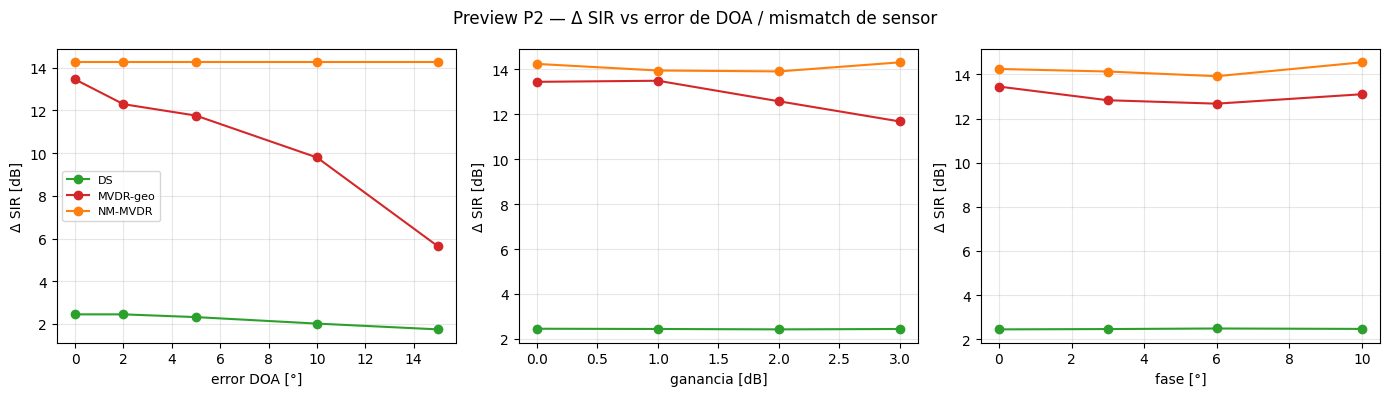

In [10]:
if all(v in globals() for v in ("df_P2_doa", "df_P2_gain", "df_P2_phase")):
    # Δ SIR vs cada barrido (DOA / ganancia / fase). Usa los df_P2_* en memoria.
    import matplotlib.pyplot as plt
    _pr = ["DS", "MVDR-geo", "NM-MVDR"]
    _c  = {"DS":"tab:green", "MVDR-geo":"tab:red", "NM-MVDR":"tab:orange"}
    def _prev(df, xcol, xlabel, ax):
        for pr in _pr:
            s = df[df.processor == pr]
            if s.empty: continue
            g = s.groupby(xcol)["Delta_tot_SIR_early"].mean()
            ax.plot(g.index.values, g.values, "-o", color=_c[pr], label=pr)
        ax.set_xlabel(xlabel); ax.set_ylabel("Δ SIR [dB]"); ax.grid(alpha=0.3)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    _prev(df_P2_doa,   "error_angle_deg", "error DOA [°]",   axes[0])
    _prev(df_P2_gain,  "mismatch_gain",   "ganancia [dB]",   axes[1])
    _prev(df_P2_phase, "mismatch_phase",  "fase [°]",        axes[2])
    axes[0].legend(fontsize=8)
    plt.suptitle("Preview P2 — Δ SIR vs error de DOA / mismatch de sensor")
    plt.tight_layout(); plt.show()
else:
    print("[i] Preview P2: corré P2 en esta sesión para verlo.")


## P3 — techos oracle: ¿error de máscara o límite del modelo?

Mismo core (Souden-MVDR recursivo / MVDR clásico), mismo framing STFT, misma fórmula
de carga diagonal (`max(rel·tr(Φ_NN)/M, piso)`) y mismo `alpha`: lo único que cambia es
**de dónde sale la información espacial**, así que cada diferencia es atribuible.

| procesador | info del target | info del ruido | qué techo marca |
|---|---|---|---|
| `NM-MVDR` | máscara DTLN (de la mezcla) | máscara DTLN | el sistema real |
| `Oracle-mask` | máscara ideal (de las limpias) | máscara ideal | **techo del NM-MVDR** |
| `Oracle-SCM` | Φ_SS de las limpias | Φ_NN de las limpias | **techo del MVDR en sí** |
| `MVDR-geo+SCM-oracle` | steering vector **geométrico** | Φ_NN de las limpias | **techo del geométrico** |

Descomposición de la brecha, por celda:
`(Oracle-SCM − NM-MVDR)` = `(Oracle-mask − NM-MVDR)` **error de máscara**
`+ (Oracle-SCM − Oracle-mask)` **límite del modelo de máscara**.

Y en paralelo, `(Oracle-SCM − MVDR-geo+SCM-oracle)` = **costo del modelo geométrico**:
misma Φ_NN ideal en ambos, la única diferencia es reemplazar Φ_SS por un steering
vector de campo cercano. Es la contracara de P1/P2 sin el ruido de la estimación:
si esa brecha crece con RT60, el problema del geométrico es el *modelo*, no el VAD.

El geométrico recibe la posición **verdadera** (`error_*`=0), igual que en P1, y
corre con carga relativa `1e-2` (su mejor punto medido) mientras la familia
mask-based usa `1e-6`: **misma fórmula** de carga en todos, cada uno en el valor
donde rinde mejor, así que ninguna brecha es atribuible a haber sub-regularizado a
alguno. Ver la nota de carga diagonal en la intro y el comentario en Config.

Acústica moderada pero con las dos variables que rompen a DTLN y no a los oracles:
**RT60** (0.16 / 0.36 / 0.61 s) e **iSIR** (−5 → 10 dB). Todo lo demás fijo
(broadside, 1 m, 2 interferentes, sin mismatch ni error de DOA, WPE apagado) y el
**post-filtro DTLN apagado** (`apply_dtln_post=False`) para que se mida el
beamformer solo, sin la cascada tapando la brecha.


In [11]:
if RUN_P3:
    # 3 RT60 x 4 iSIR x 2 locutores = 24 celdas x 4 procesadores = 96 filas.
    # Diversidad deliberadamente chica en lo geometrico (todo broadside a 1 m) y
    # concentrada en los dos ejes que degradan la MASCARA: reverberacion y cuanta
    # interferencia hay. Los oracles no dependen de estimar nada de la mezcla, asi
    # que su curva marca el piso de la degradacion "fisica" y todo lo que se abra
    # por debajo es error de mascara.
    INTERF_P3 = [[(30, 1.0, 0), (-45, 1.0, 1)]]      # 2 interferentes, layout fijo
    grid_P3 = dict(
        rt60=[0.160, 0.360, 0.610],
        isir_db=[-5, 0, 5, 10],
        target_angle=[0], target_dist=[1.0],
        source_path=TARGETS,
        interf_configs=INTERF_P3,
        use_wpe=[False],
        mismatch_gain=[0], mismatch_phase=[0],
        error_angle_deg=[0.0], error_distance_m=[0.0],
    )
    # apply_dtln_post=False -> no se corre la cascada BF->DTLN (no aplica en P3).
    # Las columnas dtln_alone_* SI se calculan igual: sirven de referencia del
    # denoiser mono solo, que es justo donde se ve que DTLN se cae con RT60 alto.
    df_P3, dir_P3 = run(grid_P3, "P3_oracle_gap", procs=processors_P3,
                        apply_dtln_post=False)
else:
    print("[i] P3 salteada (RUN_P3=False).")


[*] t_early FIXED at 50.0 ms (decoupled from wpe_delay).
[*] Total experiments to run: 24 per processor (1 processors -> 24 rows).


MIRD Benchmark   0%|          | 0/24 exp [00:00<?, ?exp/s]

   0%|          | 0/1


=== BATCH COMPLETED IN 2.63 MINUTES ===
[EXITO] P3_oracle_gap -> /content/drive/MyDrive/Tesis_Beamformers/results_fases/F1_20260829_025346/P3_oracle_gap  (24 filas, 1 proc, 24 celdas)


/tmp/ipykernel_2187/2572028829.py:150: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "finished_utc": datetime.utcnow().isoformat() + "Z"},


### Preview rápido P3 (brecha al oracle, en memoria)

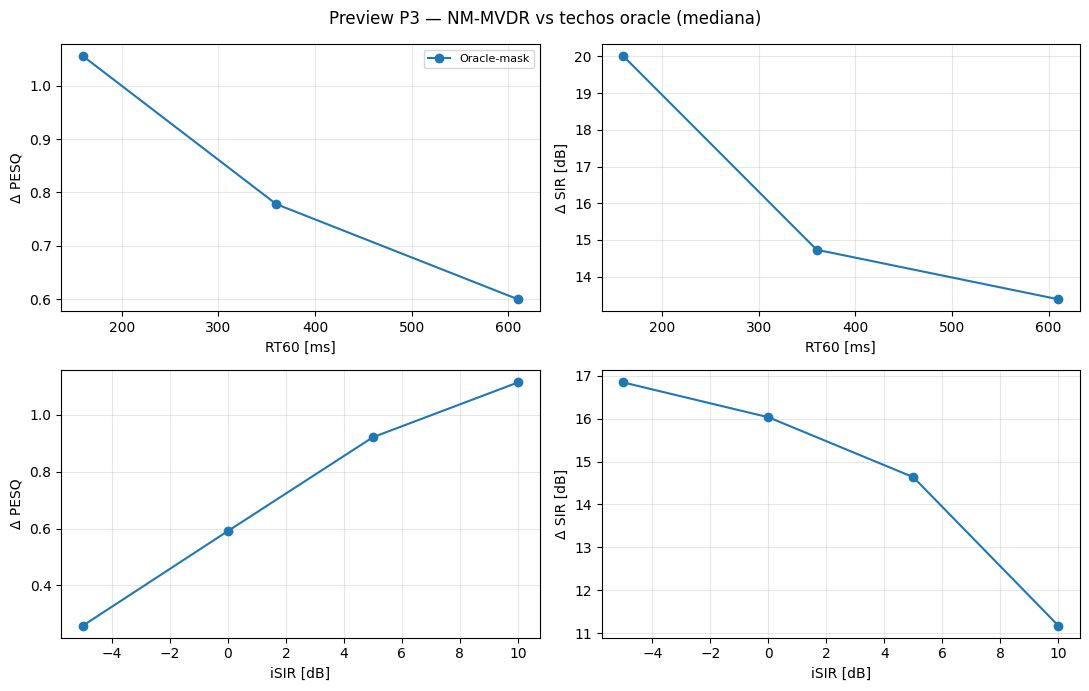

In [12]:
if "df_P3" in globals():
    # Agregacion por MEDIANA: SIR/SAR pueden dar valores enormes (o inf) en celdas
    # de RT60 bajo, lo cual es real pero arrastra cualquier media.
    import numpy as np, matplotlib.pyplot as plt
    _d3 = df_P3.replace([np.inf, -np.inf], np.nan)
    _pr = ["NM-MVDR", "Oracle-mask", "Oracle-SCM", "MVDR-geo+SCM-oracle"]
    _c  = {"NM-MVDR": "tab:orange", "Oracle-mask": "tab:blue",
           "Oracle-SCM": "tab:purple", "MVDR-geo+SCM-oracle": "tab:red"}
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    for row, (xcol, xlab, xscale) in enumerate([("rt60", "RT60 [ms]", 1000.0),
                                                ("isir_db", "iSIR [dB]", 1.0)]):
        for ax, (col, lbl) in zip(axes[row], [("Delta_tot_PESQ_early", "Δ PESQ"),
                                              ("Delta_tot_SIR_early", "Δ SIR [dB]")]):
            for pr in _pr:
                s = _d3[_d3.processor == pr]
                if s.empty: continue
                g = s.groupby(xcol)[col].median()
                ax.plot(g.index.values * xscale, g.values, "-o", color=_c[pr], label=pr)
            ax.set_xlabel(xlab); ax.set_ylabel(lbl); ax.grid(alpha=0.3)
    axes[0, 0].legend(fontsize=8)
    plt.suptitle("Preview P3 — NM-MVDR vs techos oracle (mediana)")
    plt.tight_layout(); plt.show()
else:
    print("[i] Preview P3: corré P3 en esta sesión para verlo.")


## Figuras — P1 (envelope general), P2 (curvas de robustez) y P3 (techos oracle)

/tmp/ipykernel_2187/3308615632.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfp1, x="processor", y=col, order=PROCS, palette=PAL, ax=ax, fliersize=1)
/tmp/ipykernel_2187/3308615632.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfp1, x="processor", y=col, order=PROCS, palette=PAL, ax=ax, fliersize=1)
/tmp/ipykernel_2187/3308615632.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfp1, x="processor", y=col, order=PROCS, palette=PAL, ax=ax, fliersize=1)
/tmp/ipykernel_2187/3308615632.py:15: FutureWarning: 

Pas

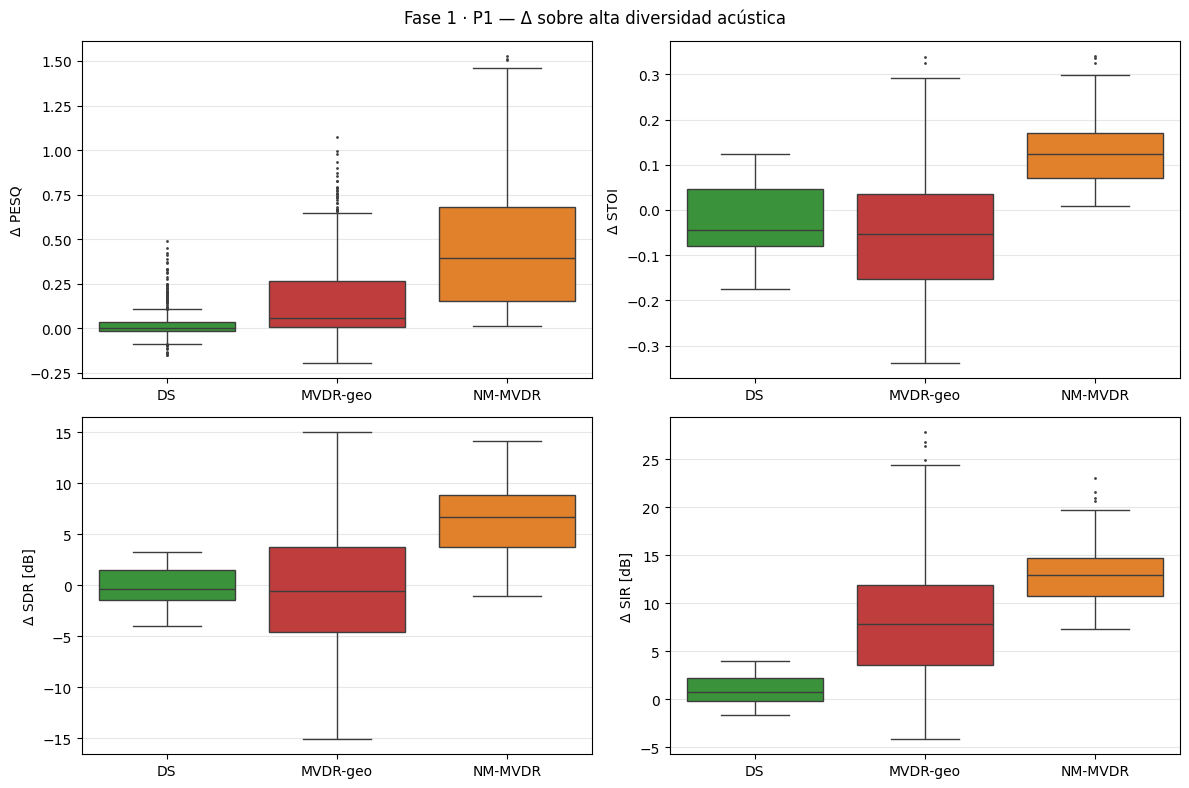

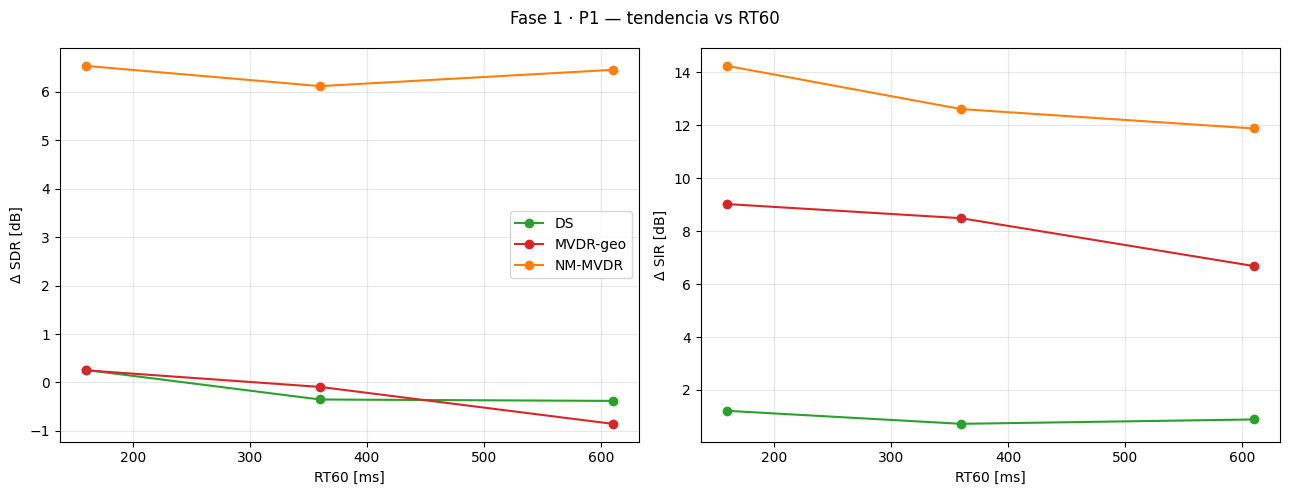

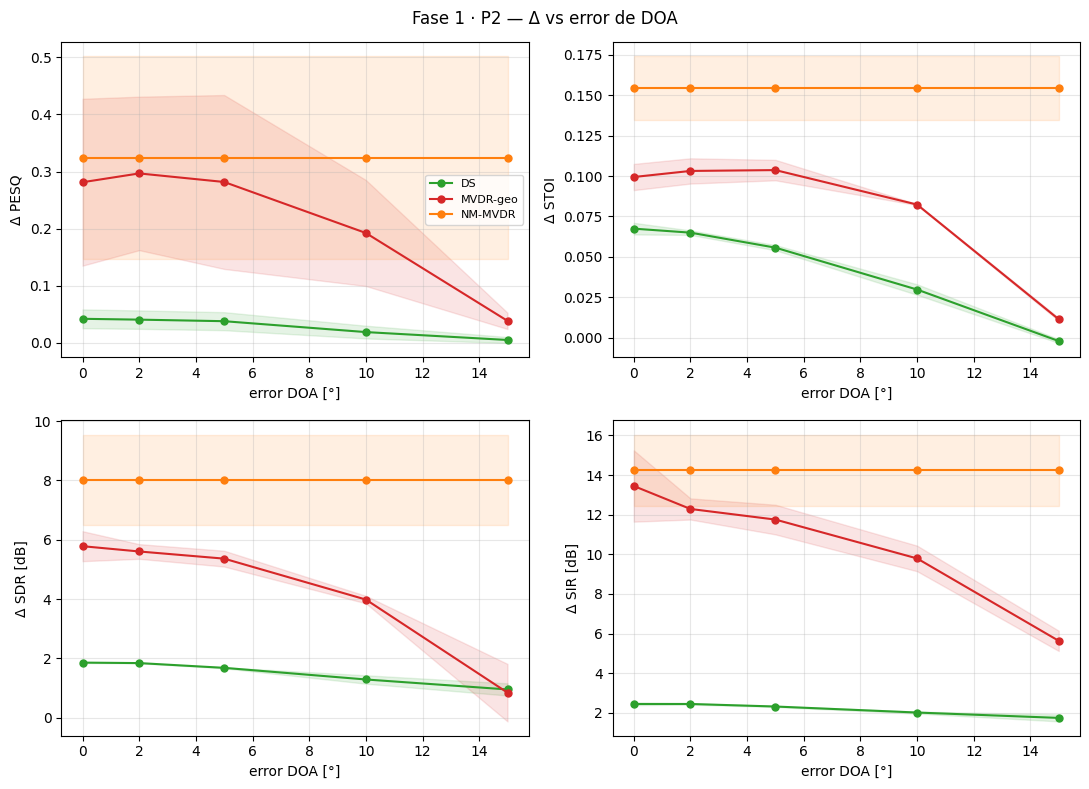

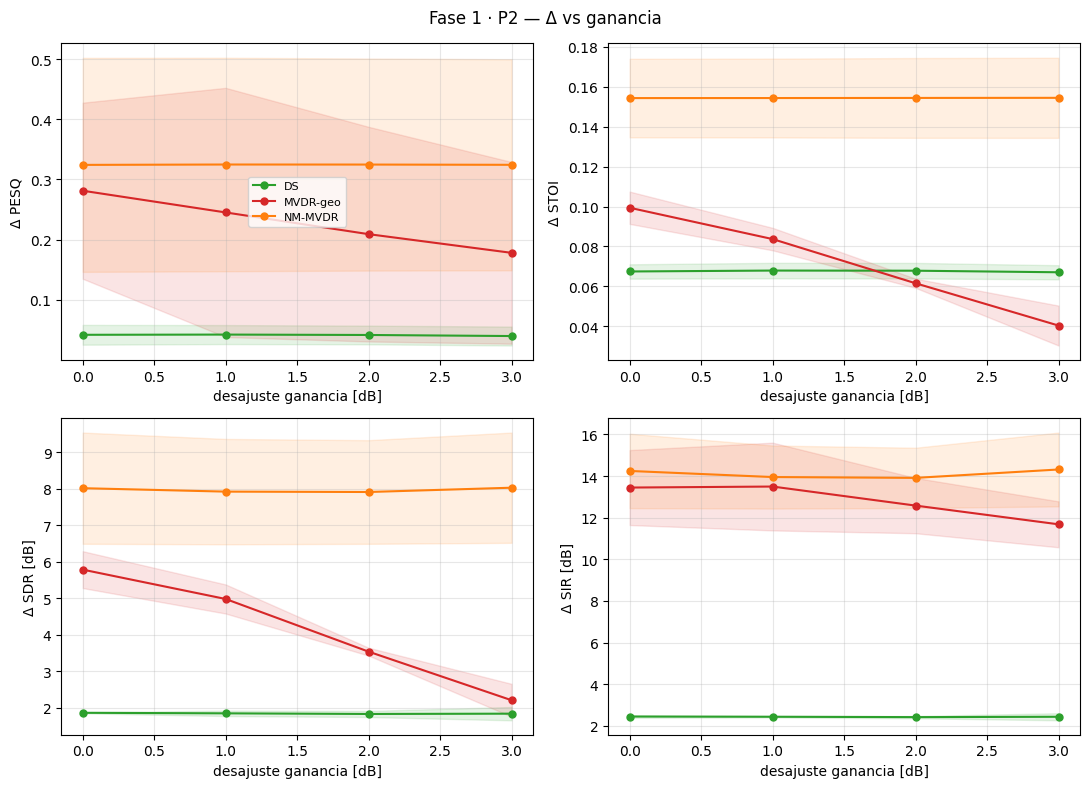

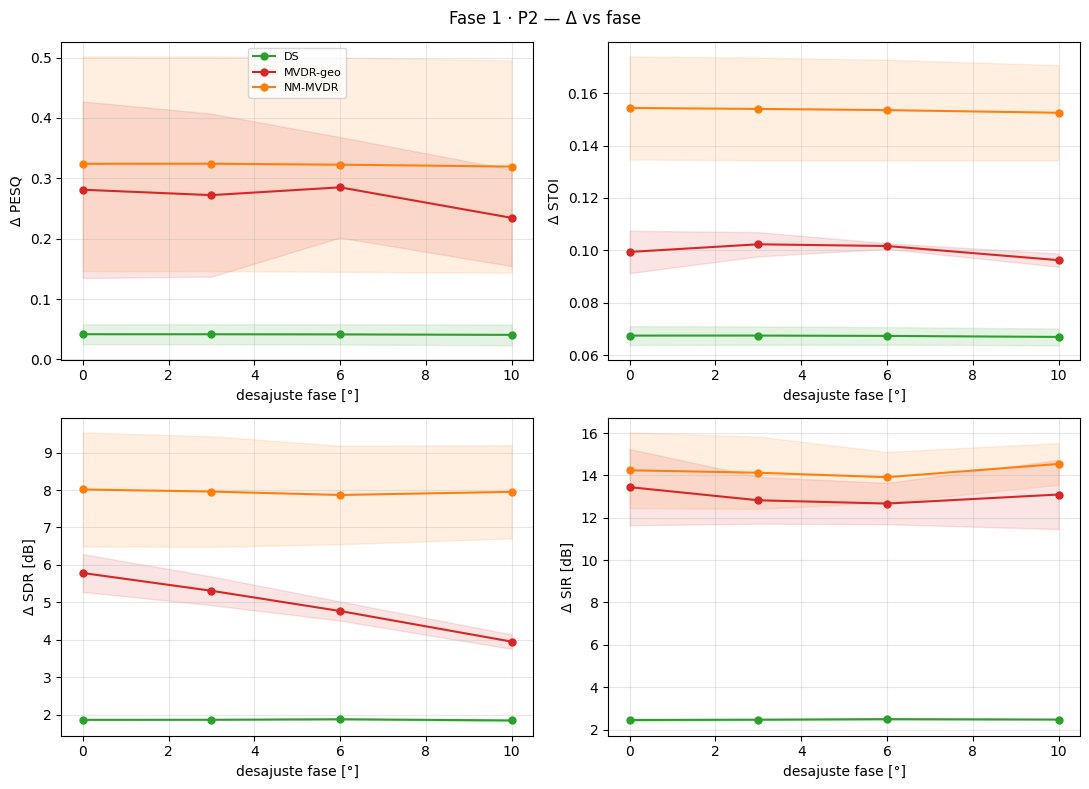

In [13]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns

METR  = [("Delta_tot_PESQ_early","Δ PESQ"), ("Delta_tot_STOI_early","Δ STOI"),
         ("Delta_tot_SDR_early","Δ SDR [dB]"), ("Delta_tot_SIR_early","Δ SIR [dB]")]
PROCS = ["DS", "MVDR-geo", "NM-MVDR"]
PAL   = {"DS":"tab:green", "MVDR-geo":"tab:red", "NM-MVDR":"tab:orange"}

# --- P1: boxplots marginales por procesador (dispersión = incertidumbre real) ---
def fig_p1(dir_p1):
    dfp1 = pd.read_csv(os.path.join(dir_p1, "mird_benchmark_metrics.csv"))
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax,(col,lbl) in zip(axes.ravel(), METR):
        if col not in dfp1.columns: continue
        sns.boxplot(data=dfp1, x="processor", y=col, order=PROCS, palette=PAL, ax=ax, fliersize=1)
        ax.set_xlabel(""); ax.set_ylabel(lbl); ax.grid(alpha=0.3, axis="y")
    fig.suptitle("Fase 1 · P1 — Δ sobre alta diversidad acústica")
    fig.tight_layout(); fig.savefig(os.path.join(dir_p1,"F1_P1_box.png"), dpi=140, bbox_inches="tight"); plt.show()

    # tendencia media vs RT60 (SDR/SIR)
    fig2, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax,(col,lbl) in zip(axes, METR[2:]):
        for pr in PROCS:
            g = dfp1[dfp1.processor==pr].groupby("rt60")[col].mean()
            ax.plot(g.index.values*1000, g.values, "-o", color=PAL[pr], label=pr)
        ax.set_xlabel("RT60 [ms]"); ax.set_ylabel(lbl); ax.grid(alpha=0.3)
    axes[0].legend()
    fig2.suptitle("Fase 1 · P1 — tendencia vs RT60"); fig2.tight_layout()
    fig2.savefig(os.path.join(dir_p1,"F1_P1_rt.png"), dpi=140, bbox_inches="tight"); plt.show()

if "dir_P1" in globals():
    fig_p1(dir_P1)
else:
    print("[i] Corré P1 para las figuras de envelope general.")

# --- P2: curvas 1D (el cruce geométrico -> ciego) ---
def plot_curves(dir_csv, xcol, xlabel, title, fname):
    df = pd.read_csv(os.path.join(dir_csv, "mird_benchmark_metrics.csv"))
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax,(col,lbl) in zip(axes.ravel(), METR):
        if col not in df.columns: continue
        for pr in PROCS:
            sub = df[df.processor==pr]
            if sub.empty: continue
            g = sub.groupby(xcol)[col]; m, s = g.mean(), g.std()
            ax.plot(m.index.values, m.values, "-o", color=PAL[pr], ms=5, label=pr)
            ax.fill_between(m.index.values, (m-s).values, (m+s).values, color=PAL[pr], alpha=0.12)
        ax.set_xlabel(xlabel); ax.set_ylabel(lbl); ax.grid(alpha=0.3)
    axes.ravel()[0].legend(fontsize=8)
    fig.suptitle(title); fig.tight_layout()
    fig.savefig(os.path.join(dir_csv, fname), dpi=140, bbox_inches="tight"); plt.show()

if all(v in globals() for v in ["dir_P2_doa", "dir_P2_gain", "dir_P2_phase"]):
    plot_curves(dir_P2_doa,   "error_angle_deg", "error DOA [°]",           "Fase 1 · P2 — Δ vs error de DOA",  "F1_P2_doa.png")
    plot_curves(dir_P2_gain,  "mismatch_gain",   "desajuste ganancia [dB]", "Fase 1 · P2 — Δ vs ganancia",     "F1_P2_gain.png")
    plot_curves(dir_P2_phase, "mismatch_phase",  "desajuste fase [°]",      "Fase 1 · P2 — Δ vs fase",         "F1_P2_phase.png")
else:
    print("[i] Corré P2 (doa/gain/phase) para las curvas de robustez de esta figura.")

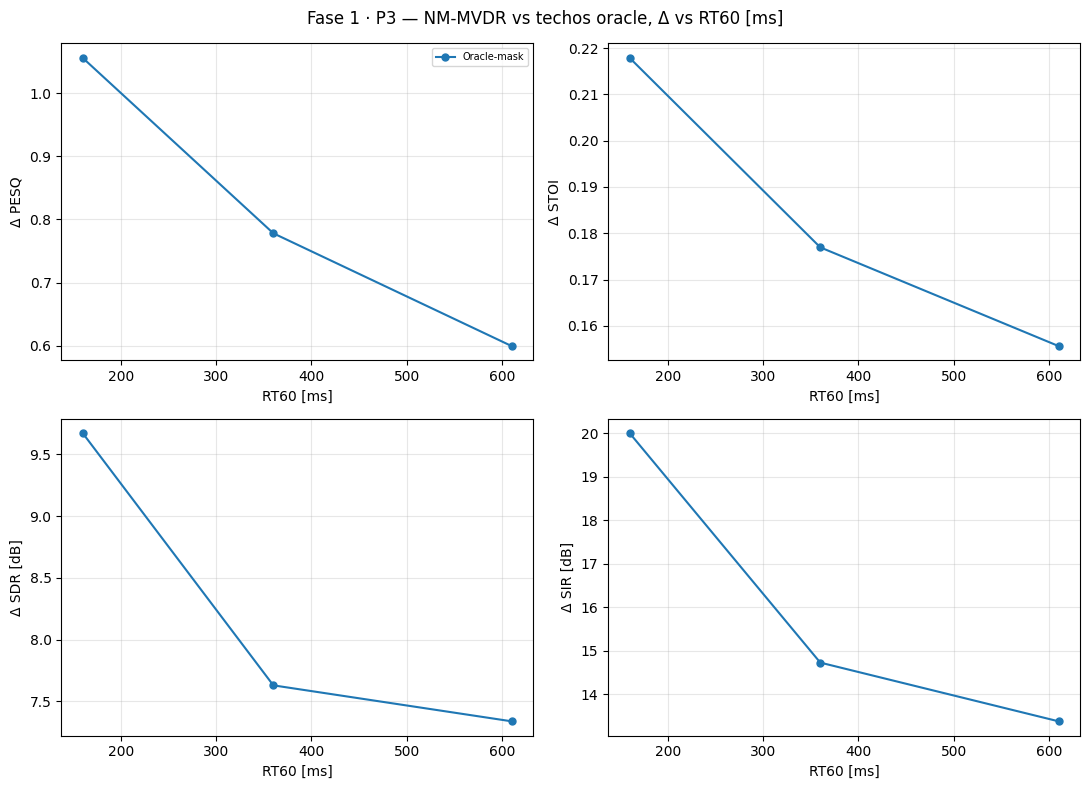

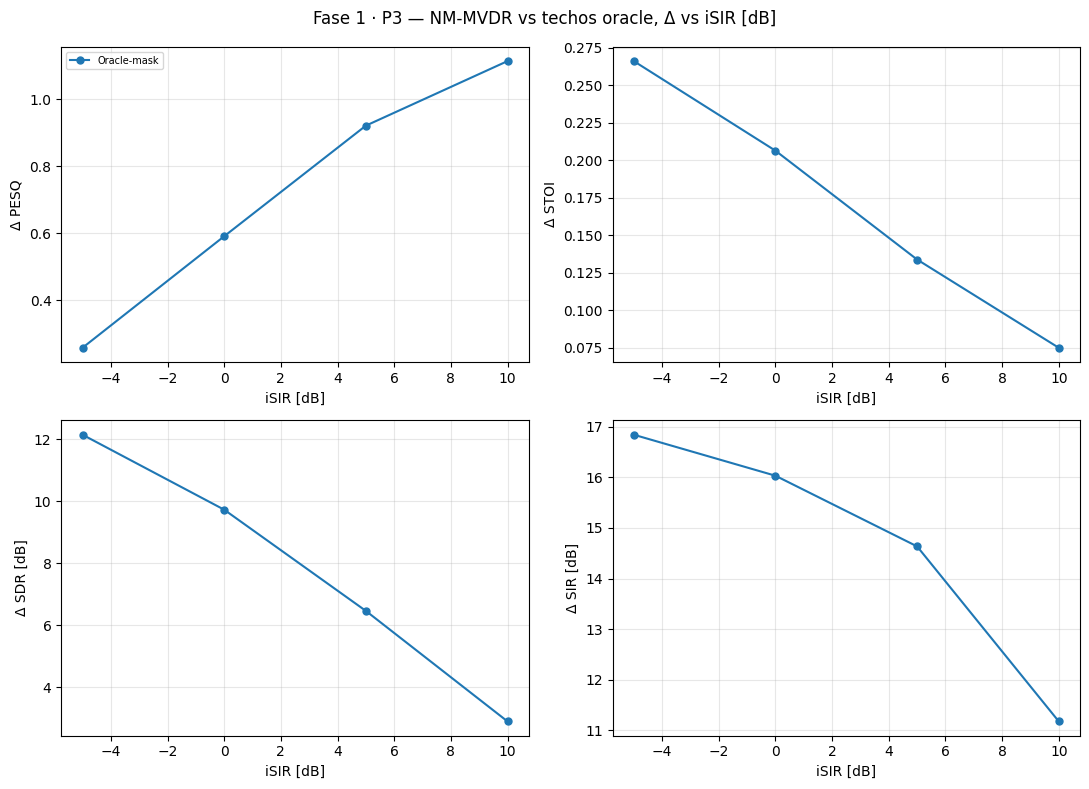

/tmp/ipykernel_2187/2604427309.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.ravel()[0].legend(fontsize=7)


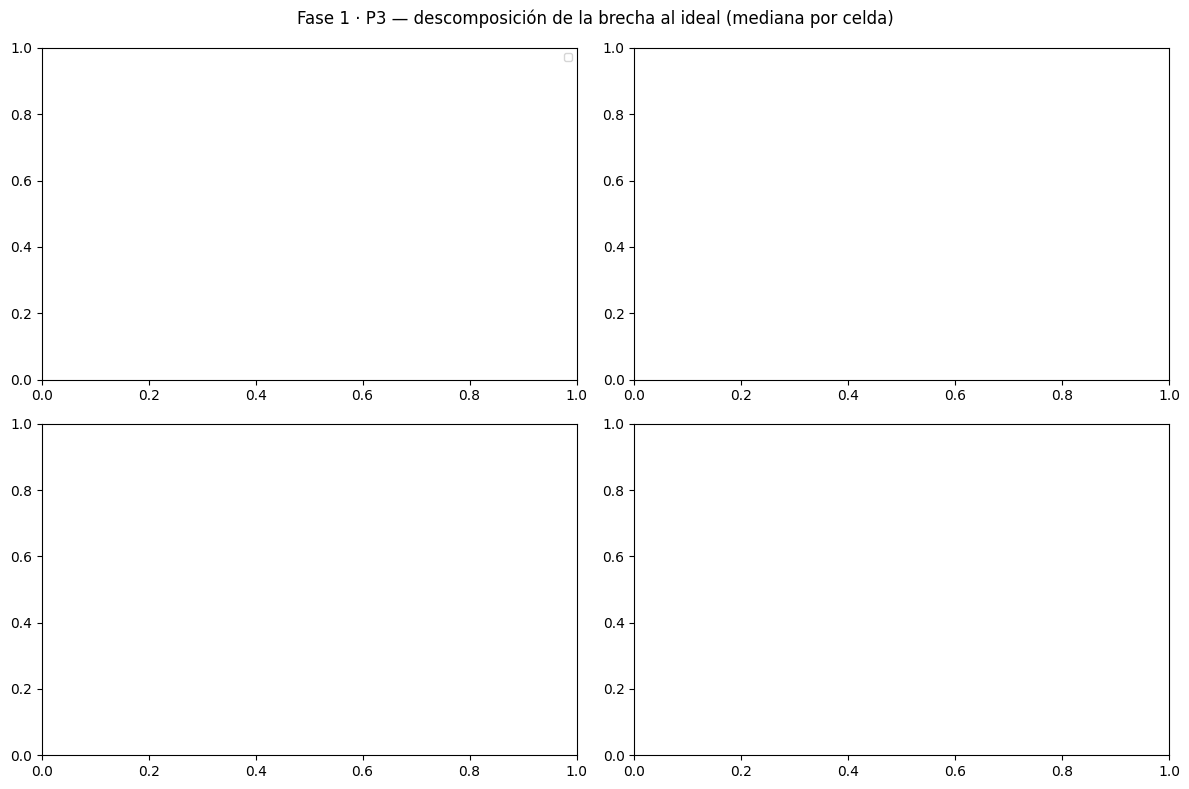

                  Delta_tot_PESQ_early  Delta_tot_STOI_early  Delta_tot_SDR_early  Delta_tot_SIR_early
processor   rt60                                                                                      
Oracle-mask 0.16                 1.056                 0.218                9.670               20.007
            0.36                 0.778                 0.177                7.631               14.733
            0.61                 0.600                 0.156                7.340               13.383


In [14]:
# --- P3: techos oracle y descomposición de la brecha ---
# Todo por MEDIANA (SIR/SAR tienen colas extremas legitimas en RT60 bajo).
if "dir_P3" in globals():
    import pandas as pd, numpy as np, matplotlib.pyplot as plt, os
    GEO3   = "MVDR-geo+SCM-oracle"
    PROCS3 = ["NM-MVDR", "Oracle-mask", "Oracle-SCM", GEO3]
    PAL3   = {"NM-MVDR": "tab:orange", "Oracle-mask": "tab:blue",
              "Oracle-SCM": "tab:purple", GEO3: "tab:red"}
    # inf -> NaN una sola vez: SIR/SAR pueden ser inf en celdas de RT60 bajo
    # (es real, no un bug), pero rompe cualquier agregado o barra apilada.
    dfp3 = (pd.read_csv(os.path.join(dir_P3, "mird_benchmark_metrics.csv"))
              .replace([np.inf, -np.inf], np.nan))
    PRES = [p for p in PROCS3 if p in set(dfp3.processor)]   # tolera corridas viejas

    # (a) curvas vs RT60 y vs iSIR para las 4 metricas
    for xcol, xlab, xscale, fname in [("rt60", "RT60 [ms]", 1000.0, "F1_P3_rt.png"),
                                      ("isir_db", "iSIR [dB]", 1.0, "F1_P3_isir.png")]:
        fig, axes = plt.subplots(2, 2, figsize=(11, 8))
        for ax, (col, lbl) in zip(axes.ravel(), METR):
            if col not in dfp3.columns: continue
            for pr in PRES:
                sub = dfp3[dfp3.processor == pr]
                if sub.empty: continue
                g = sub.groupby(xcol)[col].median()
                ax.plot(g.index.values * xscale, g.values, "-o", color=PAL3[pr], ms=5, label=pr)
            ax.set_xlabel(xlab); ax.set_ylabel(lbl); ax.grid(alpha=0.3)
        axes.ravel()[0].legend(fontsize=7)
        fig.suptitle(f"Fase 1 · P3 — NM-MVDR vs techos oracle, Δ vs {xlab}")
        fig.tight_layout(); fig.savefig(os.path.join(dir_P3, fname), dpi=140, bbox_inches="tight"); plt.show()

    # --- pivot por CELDA: cada fila es una escena, cada columna un procesador.
    # Restar celda a celda (y recien despues agregar) evita comparar medianas de
    # poblaciones distintas si alguna celda fallara en un procesador.
    CELL = [c for c in ["rt60", "isir_db", "source", "target_angle", "target_dist"]
            if c in dfp3.columns]
    PIV = {col: dfp3.pivot_table(index=CELL, columns="processor", values=col, aggfunc="median")
           for col, _ in METR if col in dfp3.columns}

    # (b) descomposicion de la brecha del camino mask-based, celda a celda:
    #     error de mascara   = Oracle-mask - NM-MVDR   (lo recuperable con mejor mascara)
    #     limite del modelo  = Oracle-SCM  - Oracle-mask (lo que ni la mascara ideal da)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, (col, lbl) in zip(axes.ravel(), METR):
        piv = PIV.get(col)
        if piv is None or not {"NM-MVDR", "Oracle-mask", "Oracle-SCM"}.issubset(piv.columns):
            continue
        gap_mask  = (piv["Oracle-mask"] - piv["NM-MVDR"]).groupby(level="rt60").median()
        gap_model = (piv["Oracle-SCM"] - piv["Oracle-mask"]).groupby(level="rt60").median()
        x = np.arange(len(gap_mask)); w = 0.6
        ax.bar(x, gap_mask.values, w, color="tab:blue", label="error de máscara\n(Oracle-mask − NM-MVDR)")
        ax.bar(x, gap_model.values, w, bottom=gap_mask.values, color="tab:purple",
               label="límite del modelo\n(Oracle-SCM − Oracle-mask)")
        ax.set_xticks(x); ax.set_xticklabels([f"{v*1000:.0f}" for v in gap_mask.index.values])
        ax.set_xlabel("RT60 [ms]"); ax.set_ylabel(f"brecha en {lbl}")
        ax.axhline(0, color="k", lw=0.8); ax.grid(alpha=0.3, axis="y")
    axes.ravel()[0].legend(fontsize=7)
    fig.suptitle("Fase 1 · P3 — descomposición de la brecha al ideal (mediana por celda)")
    fig.tight_layout(); fig.savefig(os.path.join(dir_P3, "F1_P3_gap.png"), dpi=140, bbox_inches="tight"); plt.show()

    # (c) penalizacion de cada modelo respecto del techo Oracle-SCM, por RT60.
    #     El geometrico entra aca: comparte la Phi_NN oracle con el techo, asi que
    #     su barra es EXCLUSIVAMENTE el costo del steering vector geometrico.
    PEN = [p for p in ["NM-MVDR", "Oracle-mask", GEO3] if p in PRES]
    if "Oracle-SCM" in PRES and PEN:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        for ax, (col, lbl) in zip(axes.ravel(), METR):
            piv = PIV.get(col)
            if piv is None or "Oracle-SCM" not in piv.columns: continue
            bars = {pr: (piv["Oracle-SCM"] - piv[pr]).groupby(level="rt60").median()
                    for pr in PEN if pr in piv.columns}
            if not bars: continue
            rts = list(bars.values())[0].index.values
            x = np.arange(len(rts)); w = 0.8 / len(bars)
            for j, (pr, v) in enumerate(bars.items()):
                ax.bar(x + (j - (len(bars) - 1) / 2) * w, v.values, w, color=PAL3[pr], label=pr)
            ax.set_xticks(x); ax.set_xticklabels([f"{v*1000:.0f}" for v in rts])
            ax.set_xlabel("RT60 [ms]"); ax.set_ylabel(f"Oracle-SCM − proc  [{lbl}]")
            ax.axhline(0, color="k", lw=0.8); ax.grid(alpha=0.3, axis="y")
        axes.ravel()[0].legend(fontsize=7)
        fig.suptitle("Fase 1 · P3 — penalización de cada modelo respecto del techo Oracle-SCM")
        fig.tight_layout(); fig.savefig(os.path.join(dir_P3, "F1_P3_penal.png"), dpi=140, bbox_inches="tight"); plt.show()

    # (d) tabla resumen para el texto de la tesis
    tab = (dfp3.groupby(["processor", "rt60"])[[c for c, _ in METR if c in dfp3.columns]]
           .median().round(3))
    print(tab.to_string())
    tab.to_csv(os.path.join(dir_P3, "F1_P3_resumen.csv"))
else:
    print("[i] Corré P3 para las figuras de techos oracle.")
